# 06 — Full MAPPO Training with GPU-Vectorized Environments

Training run using **PyTorch GPU-vectorized environments** for high throughput.
All N_ENVS environments step in a single batched tensor operation on the GPU;
the policy forward pass runs on the same device with no framework boundary.

Curriculum progression through geometry tiers:
- **Phase 1 (Easy)**: Tier 0 open fields, 5–10 agents
- **Phase 2 (Medium)**: Tier 0–1 corridors/bottlenecks, 8–20 agents
- **Phase 3 (Hard)**: Tier 1–2 branching corridors, 15–30 agents
- **Phase 4 (Full)**: All tiers, 20–50 agents

Compact geometries (8–15m fields, 8–18m corridors) keep density high.
Episode resets run asynchronously on CPU threads while the GPU steps.

In [1]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import defaultdict

from crowdrl_core.action import ActionConfig
from crowdrl_core.observation import ObsConfig
from crowdrl_env.crowd_env import CrowdEnv, CrowdEnvConfig
from crowdrl_env.geometry_generator import GeometryTier, GeometryConfig
from crowdrl_env.reward import RewardConfig
from crowdrl_env.spawner import SpawnConfig
from crowdrl_env.visualiser import plot_geometry

from crowdrl_train.buffer import RolloutBuffer
from crowdrl_train.config import (
    NetworkConfig, PPOConfig, CurriculumConfig, CurriculumPhase,
)
from crowdrl_train.curriculum import CurriculumManager, EpisodeStats
from crowdrl_train.mappo import MAPPOUpdater
from crowdrl_train.networks import ActorCritic
from crowdrl_train.normalizer import RewardNormalizer
from crowdrl_train.train import collect_episode

from crowdrl_torch import (
    BatchedTorchEnv, TorchRolloutCollector, TorchRunningNormalizer,
    make_episode_factory,
)
from crowdrl_torch.types import EnvConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}, device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name()}")
print(f"  CPU cores: {os.cpu_count()}")

torch 2.6.0+cu126, device: cuda
  GPU: NVIDIA GeForce RTX 4090
  CPU cores: 32


## 1. Training Configuration

Key choices:
- **GPU-vectorized envs** (`N_ENVS=256`): all environments step in one batched GPU kernel via `BatchedTorchEnv`. No subprocess IPC — observations stay as `torch.Tensor` on the training device.
- **Collect 400k agent-steps** per rollout before each PPO update
- **Compact geometries**: fields 8–15m, corridors 8–18m — keeps density high
- **Progress weight** 0.1 for directional shaping
- **Wall proximity penalty** -0.3: smooth distance-based penalty for agents near walls
- **Action rate penalty** -0.05: penalises large changes in policy output between steps
- **Tightened orientation limits**: heading and torso change reduced to 15°/step (from 45°/30°)
- **max_steps=200**: 20s sim time — enough for compact geometries
- **Curriculum**: 4 phases, advance when rolling goal rate exceeds threshold
- **Async CPU resets**: 8 worker threads generate geometry (Shapely) while GPU steps

In [2]:
# --- Vectorized env config ---
N_ENVS = 64 # GPU-batched environments (no subprocess overhead)
MAX_AGENTS = 128  # max agents per episode (must be >= largest n_agents_range upper bound)
N_STEPS_PER_COLLECT = N_ENVS * 10000  # agent-steps per PPO update (10000 steps per environment means most agent finish their run)
N_ROLLOUTS = 1000  # number of collect-update cycles

# --- Curriculum phases ---
# Geometry stays compact throughout — crowding comes from agent count, not field size.
phases = (
    CurriculumPhase(
        name="easy",
        geometry_tiers=(GeometryTier.TIER_0,),
        n_agents_range=(5, 10),
        goal_rate_threshold=0.70,
    ),
    CurriculumPhase(
        name="medium",
        geometry_tiers=(GeometryTier.TIER_0, GeometryTier.TIER_1),
        n_agents_range=(8, 20),
        goal_rate_threshold=0.60,
    ),
    CurriculumPhase(
        name="hard",
        geometry_tiers=(GeometryTier.TIER_1, GeometryTier.TIER_2),
        n_agents_range=(15, 30),
        goal_rate_threshold=0.50,
    ),
    CurriculumPhase(
        name="rooms",
        geometry_tiers=(GeometryTier.TIER_2, GeometryTier.TIER_3A),
        n_agents_range=(15, 60),
        goal_rate_threshold=0.50,
    ),
    CurriculumPhase(
        name="composed",
        geometry_tiers=(GeometryTier.TIER_3A, GeometryTier.TIER_3B),
        n_agents_range=(20, 100),
        goal_rate_threshold=0.40,
    ),
    CurriculumPhase(
        name="full",
        geometry_tiers=(
            GeometryTier.TIER_0, GeometryTier.TIER_1, GeometryTier.TIER_2,
            GeometryTier.TIER_3A, GeometryTier.TIER_3B,
        ),
        n_agents_range=(20, 128),
        goal_rate_threshold=0.0,
        tier_weights=(0.05, 0.05, 0.1, 0.35, 0.45),
    ),
)

# Validate: MAX_AGENTS must cover the largest phase
_max_phase_agents = max(p.n_agents_range[1] for p in phases)
assert MAX_AGENTS >= _max_phase_agents, (
    f"MAX_AGENTS={MAX_AGENTS} but curriculum needs up to {_max_phase_agents} -- increase MAX_AGENTS"
)

curriculum_config = CurriculumConfig(
    phases=phases,
    metric_window=100,
    min_episodes_per_phase=1000,
)

# --- Observation ---
# Navmesh signals add 3D to the observation: next-waypoint direction (2D) +
# path deviation (1D). This gives agents shortest-path guidance through corridors
# and around corners, instead of relying on the raw straight-line goal direction
# which points through walls in complex geometries (Tier 1-2).
obs_config = ObsConfig(
    use_navmesh=True,  # adds funnel-algorithm waypoints to obs (79D -> 82D)
)

# --- Reward ---
reward_config = RewardConfig(
    # -- Tier 1: Sparse task rewards --
    # Large goal bonus dominates the signal — drives agents to reach their target.
    goal_bonus=20.0,
    # Per-step penalty while overlapping another agent. Teaches collision avoidance;
    # must be large enough to outweigh shortcut-through-crowd strategies.
    collision_penalty=-5.0,
    # Flat penalty at episode timeout. Discourages passive/stuck policies that
    # avoid collisions by never moving.
    timeout_penalty=-5.0,

    # -- Existence penalty --
    # Small cost every step an agent is alive. Pressures agents to reach their
    # goal quickly rather than dawdling safely. At -0.05 over 2000 steps, a
    # maximally slow agent accumulates -100 — comparable to the goal bonus.
    existence_penalty=-0.01,

    # -- Tier 2: Progress shaping --
    # Potential-based: reward = weight * (prev_dist - curr_dist). Positive when
    # approaching goal, negative when drifting. Doesn't create spurious optima.
    progress_weight=1,
    # Continuous proximity signal: weight * 1/(dist+1). Disabled -- not
    # potential-based, biases toward short-distance episodes across tiers.
    inverse_distance_weight=0.0,

    # -- Smoothness priors --
    # Penalise deviation from preferred walking speed. Kept low to avoid
    # dominating the reward budget -- existence penalty already provides
    # time pressure. Agents in congestion must slow down without being
    # penalised heavily for it.
    speed_deviation_weight=0.0,
    # Tier 2 smoothness (jerk + angular accel penalties) disabled — the action
    # rate penalty below is more direct and sufficient for now.
    use_smoothness=True,

    # -- Wall proximity --
    # Smooth penalty when agent is within threshold * body_radius of a wall.
    # Provides a learnable gradient before hard wall contact (which has zero
    # gradient). Lower than collision_penalty since wall-hugging is less
    # dangerous than agent interpenetration.
    wall_proximity_penalty=-0.1,
    wall_proximity_threshold=1.5,  # multiple of agent body radius

    # -- Agent proximity --
    # Per-step penalty when another agent is within threshold * body_radius.
    # Teaches personal-space maintenance independently of hard collision penalty.
    agent_proximity_penalty=-0.1,
    agent_proximity_threshold=2.0,  # multiple of agent body radius

    # -- Action rate --
    # Penalises ||action_t - action_{t-1}||. Targets the policy output directly,
    # discouraging oscillating/chattering actions that cause jerky movement.
    # More direct than jerk penalty (which is a 2nd derivative of position).
    action_rate_weight=-0.01,
)

# --- Action (tightened orientation limits for smoother movement) ---
action_config = ActionConfig(
    max_heading_change=np.pi / 12,  # 15 deg/step (was 45 deg)
    max_torso_change=np.pi / 12,    # 15 deg/step (was 30 deg)
)

# --- Environment base config ---
# Compact geometry: 8–15m fields, 8–18m corridors, 2–4m corridor width.
# This keeps density high and episodes short enough to learn from.
env_config = CrowdEnvConfig(
    geometry=GeometryConfig(
        min_side=8.0,
        max_side=15.0,
        corridor_width_range=(2.0, 4.0),
        corridor_length_range=(8.0, 18.0),
    ),
    obs=obs_config,
    action=action_config,
    reward=reward_config,
    max_steps=2000,  # 20s sim time — sufficient for compact geometries
)

# --- GPU env config (maps CrowdEnvConfig → flat scalar config for tensor ops) ---
torch_env_config = EnvConfig.from_crowd_env_config(
    env_config, max_agents=MAX_AGENTS, max_segments=512,
)

# --- Network ---
# obs_dim and action_dim are inferred from the env config so they stay in sync
# automatically when observation components (navmesh, two-channel rays) are toggled.
net_config = NetworkConfig(
    obs_dim=env_config.obs.obs_dim,
    action_dim=env_config.action.action_dim,
    actor_hidden_sizes=(256, 256),
    critic_hidden_sizes=(256, 256),
)

ppo_config = PPOConfig(
    lr_actor=5e-4,
    lr_critic=5e-4,
    n_epochs=10,
    clip_epsilon=0.2,
    gamma=0.99,
    gae_lambda=0.95,
    target_kl=0.02,
    lr_schedule="cosine",
)

SEED = 42
LOG_INTERVAL = 5  # print every 5 rollouts (more frequent feedback)

print(f"GPU-vectorized training: {N_ENVS} envs on {device}, {N_STEPS_PER_COLLECT} steps/collect")
print(f"Target: {N_ROLLOUTS} rollouts, MAX_AGENTS={MAX_AGENTS}")
print(f"Curriculum: {' -> '.join(p.name for p in phases)}")
print(f"Observation: {env_config.obs.obs_dim}D (navmesh={'on' if obs_config.use_navmesh else 'off'})")
print(f"max_steps={env_config.max_steps} ({env_config.max_steps * env_config.dt:.0f}s sim time)")
print(f"Geometry: fields {env_config.geometry.min_side}-{env_config.geometry.max_side}m, "
      f"corridors {env_config.geometry.corridor_length_range[0]}-"
      f"{env_config.geometry.corridor_length_range[1]}m")
print(f"Reward: progress={reward_config.progress_weight}, "
      f"inv_dist={reward_config.inverse_distance_weight}, "
      f"goal={reward_config.goal_bonus}")
print(f"  existence_penalty={reward_config.existence_penalty}, "
      f"wall_proximity_penalty={reward_config.wall_proximity_penalty}, "
      f"action_rate_weight={reward_config.action_rate_weight}")
print(f"Action: max_heading={np.degrees(action_config.max_heading_change):.0f} deg/step, "
      f"max_torso={np.degrees(action_config.max_torso_change):.0f} deg/step")


GPU-vectorized training: 64 envs on cuda, 640000 steps/collect
Target: 1000 rollouts, MAX_AGENTS=128
Curriculum: easy -> medium -> hard -> rooms -> composed -> full
Observation: 82D (navmesh=on)
max_steps=2000 (20s sim time)
Geometry: fields 8.0-15.0m, corridors 8.0-18.0m
Reward: progress=1, inv_dist=0.0, goal=20.0
  existence_penalty=-0.01, wall_proximity_penalty=-0.1, action_rate_weight=-0.01
Action: max_heading=15 deg/step, max_torso=15 deg/step


## 2. Initialise Training Components

In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

actor_critic = ActorCritic(net_config).to(device)
updater = MAPPOUpdater(actor_critic, ppo_config, device)
curriculum = CurriculumManager(curriculum_config)

# GPU-resident normalizer — observations stay on device during collect
obs_normalizer = TorchRunningNormalizer(shape=(env_config.obs.obs_dim,), device=device)
reward_normalizer = RewardNormalizer(gamma=ppo_config.gamma)

n_params = sum(p.numel() for p in actor_critic.parameters())
print(f"Actor-Critic: {n_params:,} parameters")
print(f"Starting phase: {curriculum.current_phase.name}")

Actor-Critic: 175,369 parameters
Starting phase: easy


## 3. Training Loop — GPU-Vectorized

All N_ENVS environments step in a single batched tensor operation on the GPU.
Episode resets run asynchronously on CPU threads (Shapely geometry generation).

Each rollout:
1. Collect ~400k agent-steps across all envs (single GPU forward pass + step)
2. Compute GAE with per-episode bootstrap values
3. Single PPO update on the full batch
4. Report completed episodes to curriculum manager

In [4]:
# Launch GPU-vectorized environment with torch.compile for kernel fusion
cur_env_config = curriculum.make_env_config(env_config)
episode_factory = make_episode_factory(cur_env_config)

batched_env = BatchedTorchEnv(
    n_envs=N_ENVS,
    config=torch_env_config,
    make_episode_fn=episode_factory,
    device=device,
    seed=SEED,
    n_reset_workers=N_ENVS,
    compile_step=True,  # torch.compile(mode="reduce-overhead") — CUDA graph fusion
)

collector = TorchRolloutCollector(
    batched_env, actor_critic,
    obs_normalizer, reward_normalizer, device,
    obs_dim=env_config.obs.obs_dim, action_dim=env_config.action.action_dim,
)

# Training history
history = defaultdict(list)
phase_transitions = []
total_agent_steps = 0
total_episodes = 0

# Warmup: the first call to the compiled step triggers torch.compile tracing +
# CUDA graph capture. One-time cost (~30-60s) that pays back every subsequent
# step via fused kernels. Falls back to eager if Triton compilation fails.
print("Warming up torch.compile (one-time, may take ~30-60s)...", flush=True)
warmup_start = time.time()
_states, _obs = batched_env.reset_all()
batched_env.states = _states
compiled = batched_env.warmup(n_steps=3)
warmup_elapsed = time.time() - warmup_start
if compiled:
    print(f"Compiled step ready in {warmup_elapsed:.1f}s", flush=True)
else:
    print(f"Using eager step (compile unavailable, {warmup_elapsed:.1f}s)", flush=True)

start_time = time.time()

print(f"\n{'Roll':>5} | {'Episodes':>8} | {'Steps':>12} | {'GoalRate':>8} | "
      f"{'Reward':>8} | {'Phase':>8} | {'SPS':>8}", flush=True)
print("-" * 80, flush=True)

try:
    for rollout in range(1, N_ROLLOUTS + 1):
        # --- Collect rollouts from all envs (per-env buffers) ---
        episode_stats_list = collector.collect(N_STEPS_PER_COLLECT)

        # --- GAE per env buffer + merge into single FlatBatch ---
        flat_batch = collector.compute_gae_and_flatten(
            ppo_config.gamma, ppo_config.gae_lambda,
        )

        # --- PPO update ---
        if flat_batch.batch_size > 0:
            update_metrics = updater.update(flat_batch)
        else:
            update_metrics = {}

        batch_steps = collector.total_active_agent_steps
        total_agent_steps += batch_steps
        total_episodes += len(episode_stats_list)

        # --- LR decay ---
        progress = rollout / N_ROLLOUTS
        updater.update_learning_rate(progress)

        # --- Record history ---
        for ep in episode_stats_list:
            history["goal_rate"].append(ep["goal_rate"])
            history["mean_reward"].append(ep["mean_reward"])
            history["episode_length"].append(ep["episode_length"])
            history["n_agents"].append(ep["n_agents"])
            history["phase_idx"].append(curriculum.current_phase_idx)
            history["geometry_tier"].append(ep.get("geometry_tier", "unknown"))

        if update_metrics:
            history["policy_loss"].append(update_metrics.get("policy_loss", 0))
            history["value_loss"].append(update_metrics.get("value_loss", 0))
            history["entropy"].append(update_metrics.get("entropy", 0))
            history["approx_kl"].append(update_metrics.get("approx_kl", 0))

        # --- Curriculum ---
        phase_advanced = False
        for ep in episode_stats_list:
            cs = EpisodeStats(
                goal_rate=ep["goal_rate"],
                n_agents=ep["n_agents"],
                episode_length=ep["episode_length"],
                mean_reward=ep["mean_reward"],
            )
            if curriculum.report_episode(cs):
                phase_advanced = True

        if phase_advanced:
            phase_transitions.append((total_episodes, curriculum.current_phase.name))
            cur_env_config = curriculum.make_env_config(env_config)
            # Swap the episode factory — new resets will use the updated config
            batched_env.make_episode_fn = make_episode_factory(cur_env_config)
            print(f"\n>>> Phase advanced to: {curriculum.current_phase.name} "
                  f"(episode {total_episodes})\n", flush=True)

        # --- Logging ---
        if rollout % LOG_INTERVAL == 0 and episode_stats_list:
            elapsed = time.time() - start_time
            sps = total_agent_steps / max(elapsed, 1)
            window = min(100, len(history["goal_rate"]))
            avg_gr = np.mean(history["goal_rate"][-window:])
            avg_rw = np.mean(history["mean_reward"][-window:])
            print(
                f"{rollout:>5} | {total_episodes:>8} | {total_agent_steps:>12,} | "
                f"{avg_gr:>8.3f} | {avg_rw:>8.2f} | "
                f"{curriculum.current_phase.name:>8} | {sps:>8.0f}",
                flush=True,
            )

finally:
    batched_env.close()

elapsed = time.time() - start_time
print(f"\nDone: {total_episodes} episodes, {total_agent_steps:,} agent-steps in {elapsed:.1f}s")
print(f"Throughput: {total_agent_steps / elapsed:.0f} agent-steps/sec")
print(f"Phase transitions: {phase_transitions}")

Warming up torch.compile (one-time, may take ~30-60s)...
Compiled step ready in 3.0s

 Roll | Episodes |        Steps | GoalRate |   Reward |    Phase |      SPS
--------------------------------------------------------------------------------
   10 |       15 |    6,401,953 |    1.000 |    -7.14 |     easy |   118126
   15 |       24 |    9,602,613 |    1.000 |    -7.94 |     easy |   119895
   20 |       55 |   12,803,258 |    1.000 |    -6.59 |     easy |   118954
   25 |      176 |   16,003,927 |    1.000 |    -8.06 |     easy |   116219
   30 |      284 |   19,204,439 |    0.997 |    -7.33 |     easy |   114593
   35 |      478 |   22,405,275 |    0.909 |    -7.47 |     easy |   112165
   40 |      681 |   25,605,793 |    0.998 |    -6.71 |     easy |   110752
   45 |      943 |   28,806,786 |    0.956 |    -8.47 |     easy |   109356

>>> Phase advanced to: medium (episode 1011)

   50 |     1016 |   32,008,104 |    0.958 |    -6.64 |   medium |   112655
   55 |     1022 |   35,20

## 4. Training Curves

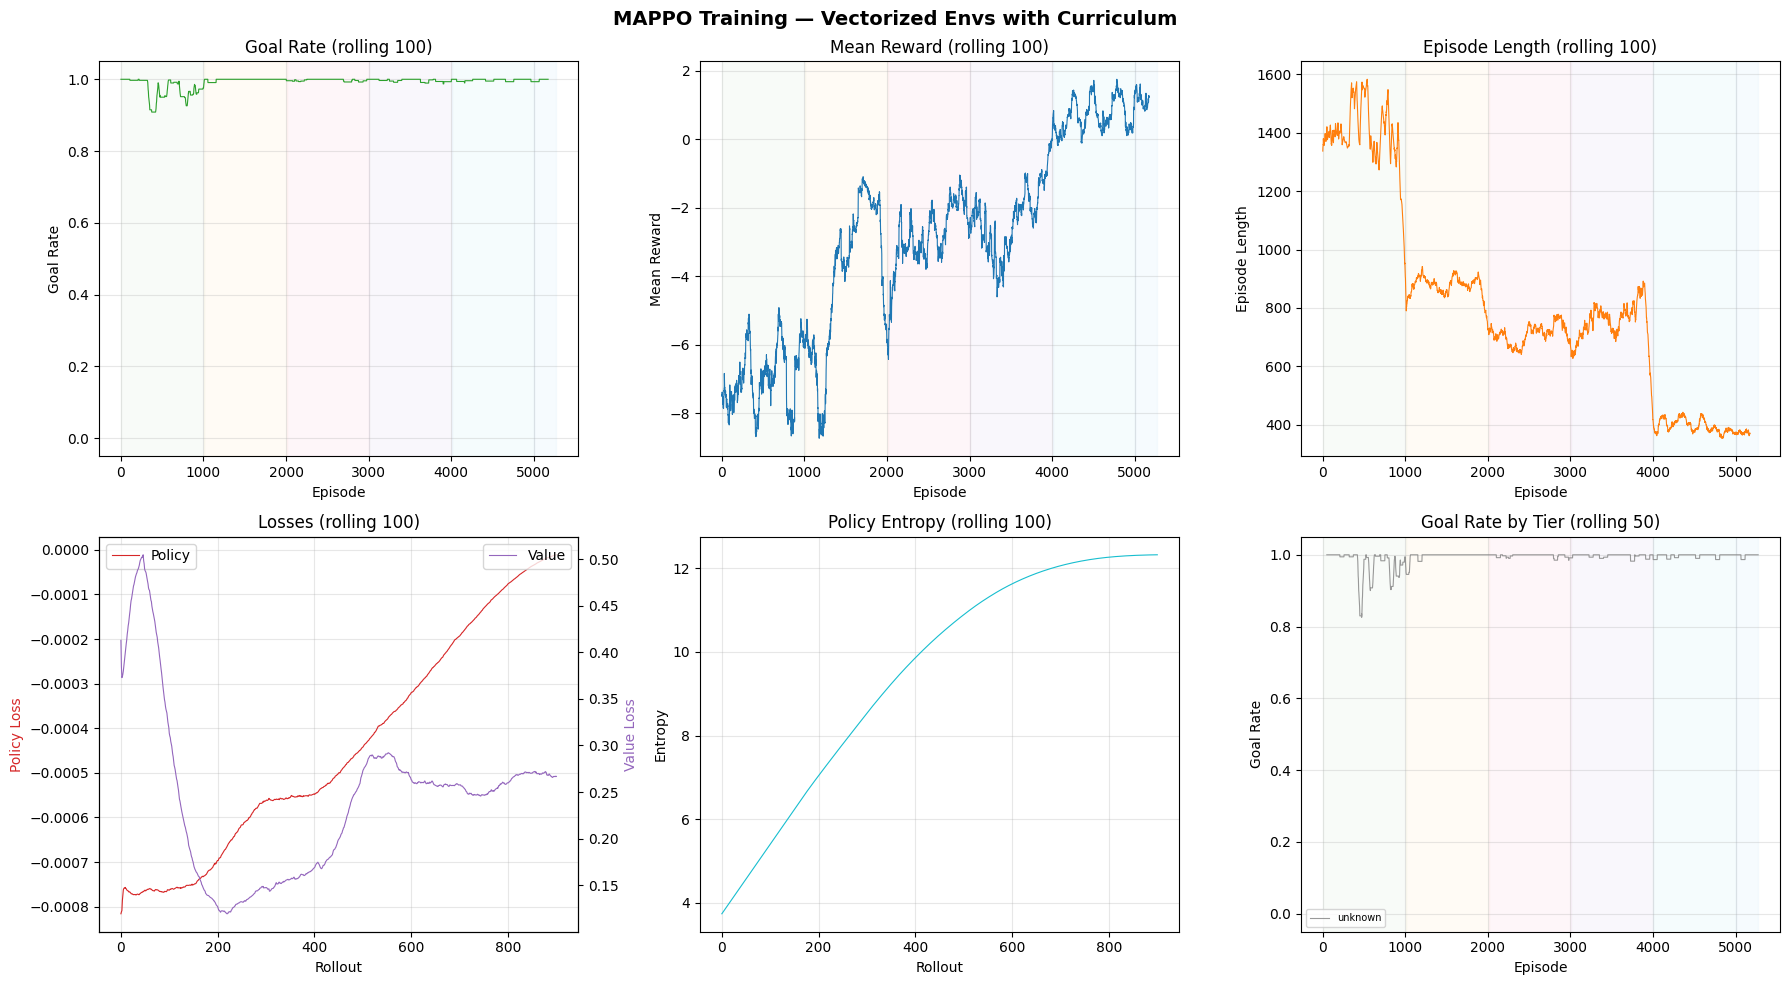

In [5]:
def smooth(values, window=100):
    """Rolling mean with edge handling."""
    if len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Phase background shading
phase_colors = ["#e8f5e9", "#fff3e0", "#fce4ec", "#ede7f6", "#e0f7fa", "#e3f2fd"]
phase_names_unique = ["easy", "medium", "hard", "rooms", "composed", "full"]

def add_phase_bg(ax):
    prev_ep = 0
    for ep_idx, name in phase_transitions:
        pidx = phase_names_unique.index(name) - 1
        if 0 <= pidx < len(phase_colors):
            ax.axvspan(prev_ep, ep_idx, alpha=0.3, color=phase_colors[pidx])
        prev_ep = ep_idx
    if phase_transitions:
        last_pidx = phase_names_unique.index(phase_transitions[-1][1])
        ax.axvspan(prev_ep, len(history["goal_rate"]), alpha=0.3,
                   color=phase_colors[min(last_pidx, len(phase_colors) - 1)])
    else:
        ax.axvspan(0, len(history["goal_rate"]), alpha=0.3, color=phase_colors[0])

# Goal rate
ax = axes[0, 0]
add_phase_bg(ax)
ax.plot(smooth(history["goal_rate"]), color="tab:green", linewidth=0.8)
ax.set_ylabel("Goal Rate")
ax.set_xlabel("Episode")
ax.set_title("Goal Rate (rolling 100)")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Mean reward
ax = axes[0, 1]
add_phase_bg(ax)
ax.plot(smooth(history["mean_reward"]), color="tab:blue", linewidth=0.8)
ax.set_ylabel("Mean Reward")
ax.set_xlabel("Episode")
ax.set_title("Mean Reward (rolling 100)")
ax.grid(True, alpha=0.3)

# Episode length
ax = axes[0, 2]
add_phase_bg(ax)
ax.plot(smooth(history["episode_length"]), color="tab:orange", linewidth=0.8)
ax.set_ylabel("Episode Length")
ax.set_xlabel("Episode")
ax.set_title("Episode Length (rolling 100)")
ax.grid(True, alpha=0.3)

# Losses
ax = axes[1, 0]
if history["policy_loss"]:
    ax.plot(smooth(history["policy_loss"]), color="tab:red", linewidth=0.8, label="Policy")
    ax2 = ax.twinx()
    ax2.plot(smooth(history["value_loss"]), color="tab:purple", linewidth=0.8, label="Value")
    ax2.set_ylabel("Value Loss", color="tab:purple")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
ax.set_ylabel("Policy Loss", color="tab:red")
ax.set_xlabel("Rollout")
ax.set_title("Losses (rolling 100)")
ax.grid(True, alpha=0.3)

# Entropy
ax = axes[1, 1]
if history["entropy"]:
    ax.plot(smooth(history["entropy"]), color="tab:cyan", linewidth=0.8)
ax.set_ylabel("Entropy")
ax.set_xlabel("Rollout")
ax.set_title("Policy Entropy (rolling 100)")
ax.grid(True, alpha=0.3)

# Per-tier goal rate (reveals whether "full" phase oscillation is tier-driven)
ax = axes[1, 2]
if history.get("geometry_tier"):
    tier_arr = np.array(history["geometry_tier"])
    tier_colors = {
        "TIER_0": "tab:green", "TIER_1": "tab:blue", "TIER_2": "tab:orange",
        "TIER_3A": "tab:red", "TIER_3B": "tab:purple",
    }
    for tier_name in sorted(set(tier_arr)):
        mask = tier_arr == tier_name
        indices = np.where(mask)[0]
        rates = np.array(history["goal_rate"])[mask]
        if len(rates) >= 20:
            smoothed = smooth(rates, window=min(50, len(rates)))
            offset = len(rates) - len(smoothed)
            ax.plot(indices[offset:], smoothed,
                    color=tier_colors.get(str(tier_name), "gray"),
                    linewidth=0.8, label=str(tier_name), alpha=0.8)
    ax.legend(fontsize=7, loc="lower left")
else:
    ax.plot(smooth(history["n_agents"]), color="tab:brown", linewidth=0.8)
    ax.set_ylabel("Agent Count")
add_phase_bg(ax)
ax.set_ylabel("Goal Rate")
ax.set_xlabel("Episode")
ax.set_title("Goal Rate by Tier (rolling 50)")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

fig.suptitle("MAPPO Training \u2014 Vectorized Envs with Curriculum", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Per-Phase Performance Summary

In [6]:
phase_idx_arr = np.array(history["phase_idx"])
goal_rate_arr = np.array(history["goal_rate"])
reward_arr = np.array(history["mean_reward"])
length_arr = np.array(history["episode_length"])
agents_arr = np.array(history["n_agents"])

print(f"{'Phase':<10} {'Episodes':>8} {'GoalRate':>10} {'Reward':>10} {'EpLen':>8} {'Agents':>8}")
print("-" * 60)
for pidx, phase in enumerate(phases):
    mask = phase_idx_arr == pidx
    if not mask.any():
        continue
    n_eps = mask.sum()
    print(
        f"{phase.name:<10} {n_eps:>8} {goal_rate_arr[mask].mean():>10.3f} "
        f"{reward_arr[mask].mean():>10.2f} {length_arr[mask].mean():>8.1f} "
        f"{agents_arr[mask].mean():>8.1f}"
    )

print(f"\nFinal 500 episodes:")
print(f"  Goal rate: {np.mean(history['goal_rate'][-500:]):.3f}")
print(f"  Mean reward: {np.mean(history['mean_reward'][-500:]):.2f}")

# Per-tier breakdown (useful for diagnosing "full" phase oscillations)
if history.get("geometry_tier"):
    tier_arr = np.array(history["geometry_tier"])
    unique_tiers = sorted(set(tier_arr))
    print(f"\n{'Tier':<12} {'Episodes':>8} {'GoalRate':>10} {'Reward':>10} {'EpLen':>8}")
    print("-" * 52)
    for tier_name in unique_tiers:
        mask = tier_arr == tier_name
        if not mask.any():
            continue
        n_eps = mask.sum()
        print(
            f"{str(tier_name):<12} {n_eps:>8} "
            f"{goal_rate_arr[mask].mean():>10.3f} "
            f"{reward_arr[mask].mean():>10.2f} "
            f"{length_arr[mask].mean():>8.1f}"
        )

Phase      Episodes   GoalRate     Reward    EpLen   Agents
------------------------------------------------------------
easy           1011      0.973      -7.00   1414.2      7.0
medium         1000      0.999      -4.01    876.0     10.0
hard            998      0.997      -3.07    712.8      5.4
rooms           996      0.996      -2.43    758.5      5.1
composed        998      0.998       0.69    397.7      4.3
full            271      0.998       1.11    373.9      4.5

Final 500 episodes:
  Goal rate: 0.999
  Mean reward: 1.02

Tier         Episodes   GoalRate     Reward    EpLen
----------------------------------------------------
unknown          5274      0.993      -2.95    809.8


## 6. Evaluation — Trajectory Visualisation

Run the trained policy on example geometries from each tier and plot agent trajectories.

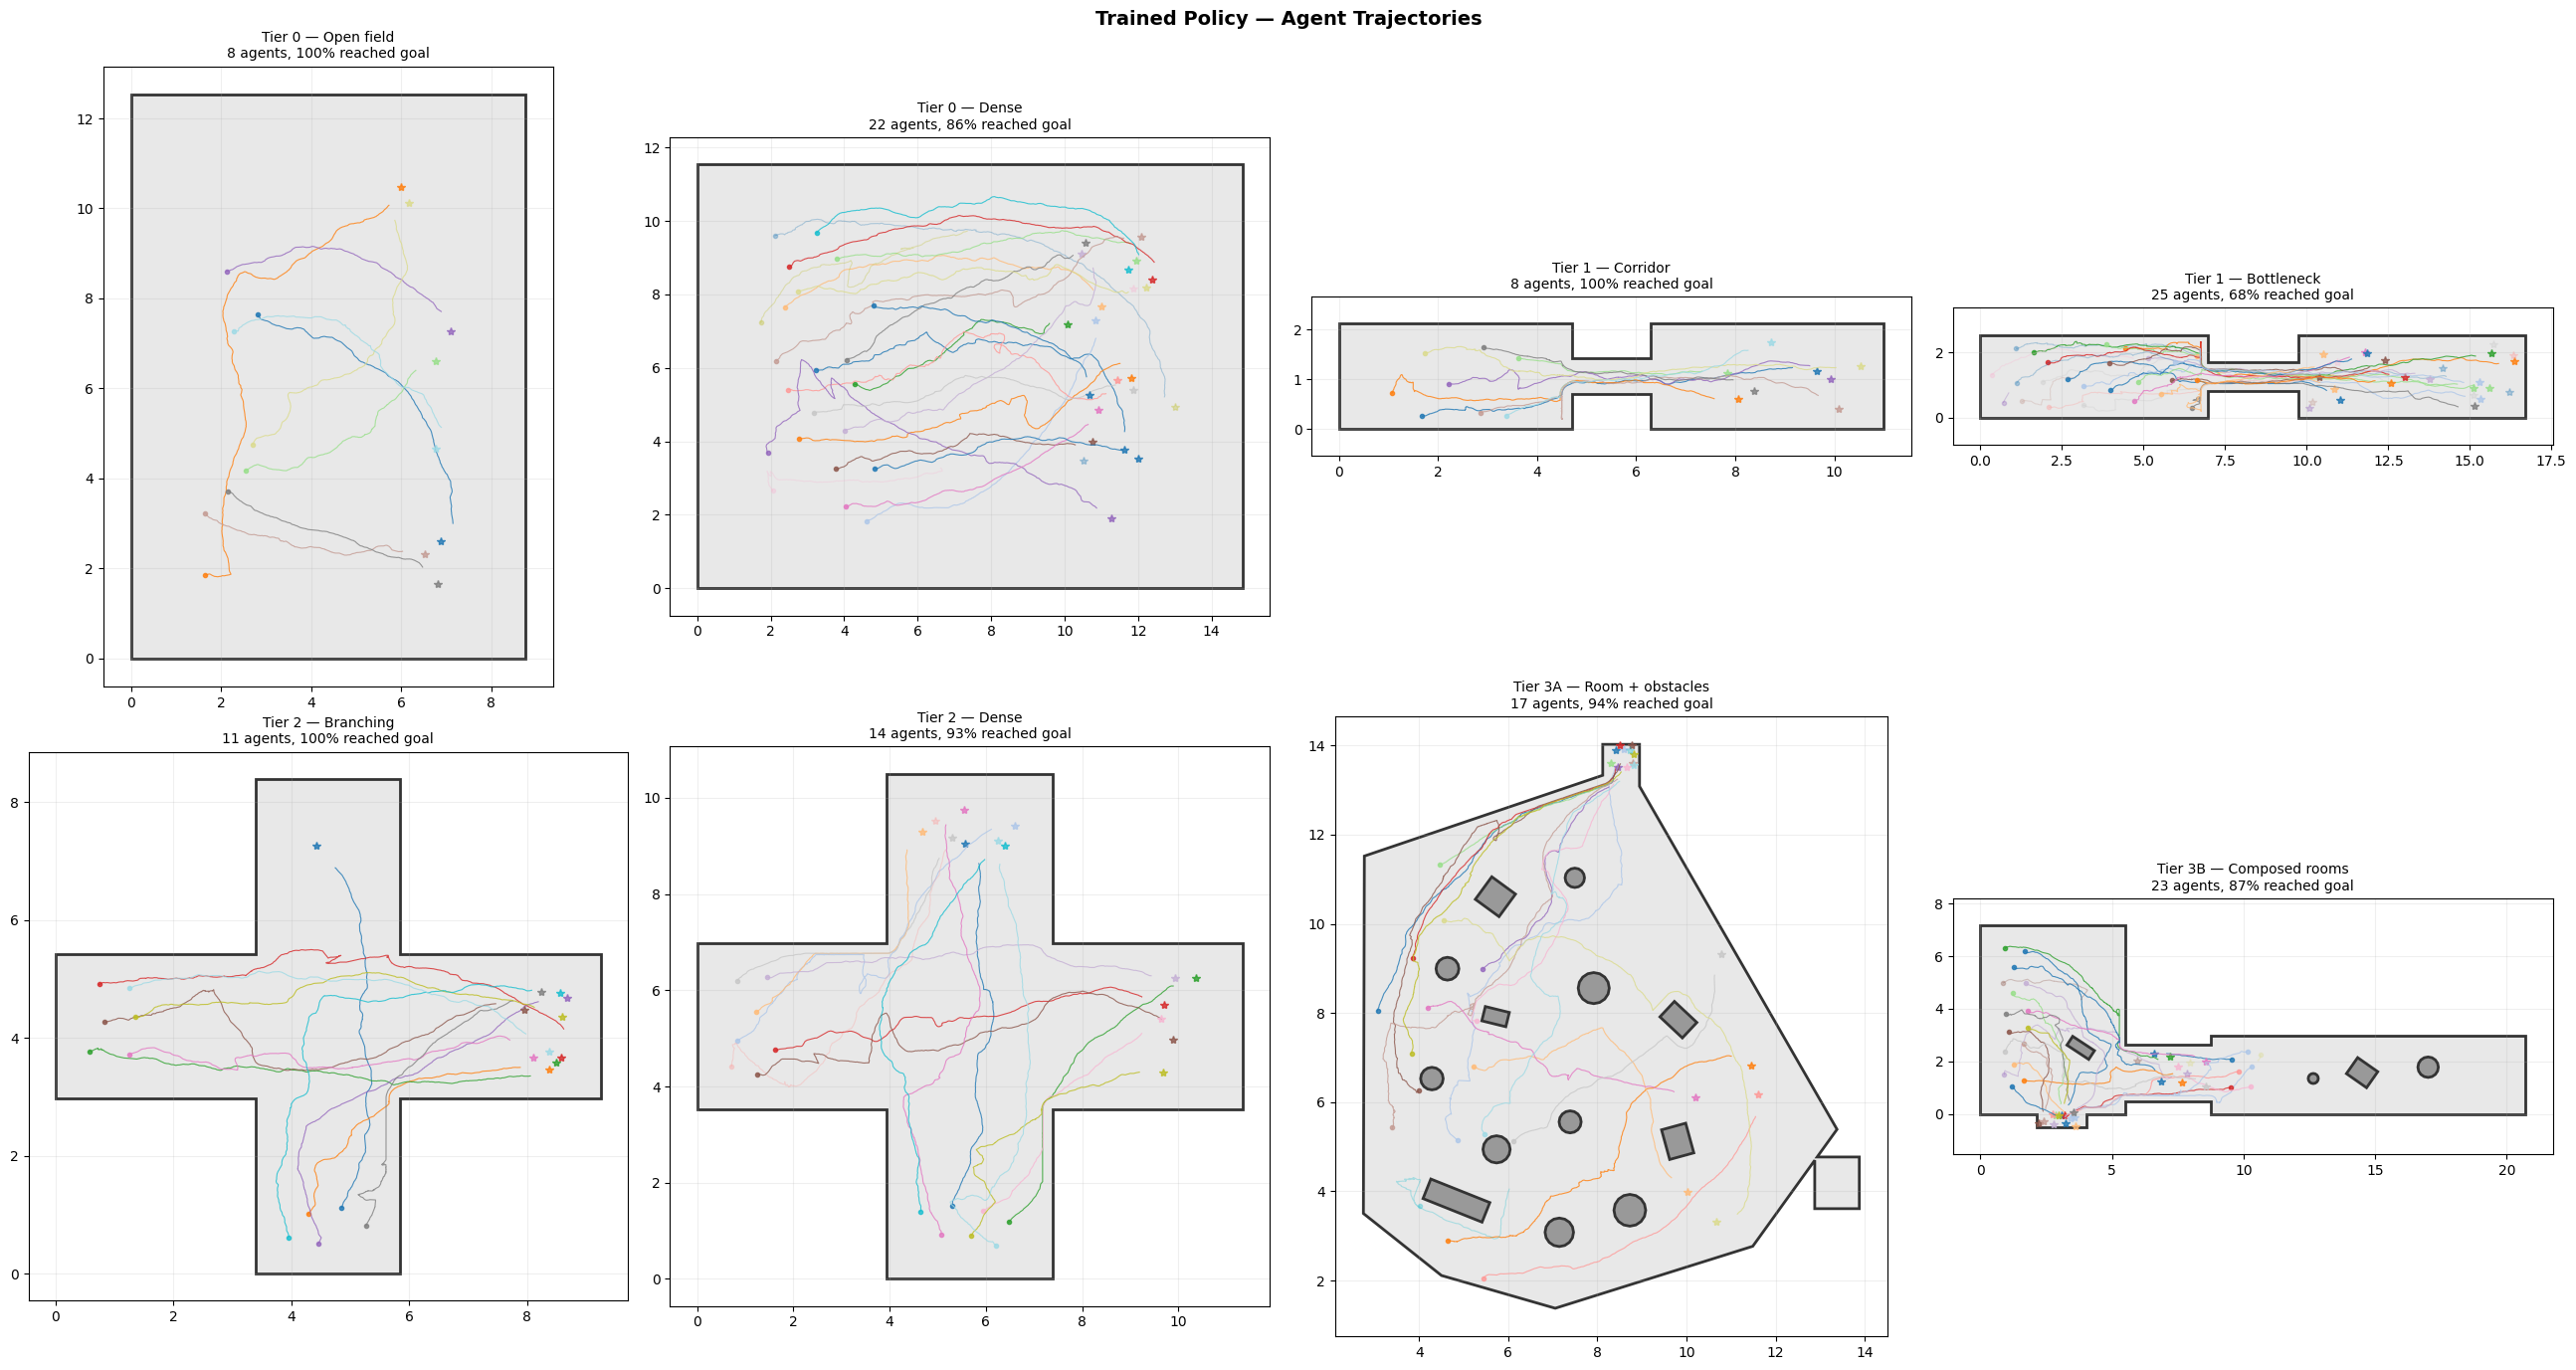

In [7]:
def run_episode_with_trajectories(env, actor_critic, obs_normalizer, device, max_steps=2000):
    """Run one episode collecting full agent trajectories."""
    obs, info = env.reset()
    n_agents = info["n_agents"]
    trajectories = [[] for _ in range(n_agents)]
    goal_positions = env._world.goal_positions.copy()
    polygon = env._world.walkable_polygon
    reached_goal = np.zeros(n_agents, dtype=bool)

    for i in range(n_agents):
        trajectories[i].append(env._world.positions[i].copy())

    for step in range(max_steps):
        # Normalise — handles both CPU (RunningNormalizer) and GPU (TorchRunningNormalizer)
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
        if obs_normalizer is not None:
            obs_norm = obs_normalizer.normalize(obs_t)
        else:
            obs_norm = obs_t

        with torch.no_grad():
            actions, _, _, _, _ = actor_critic.get_action_and_value(obs_norm)

        obs, rewards, terminated, truncated, step_info = env.step(actions.cpu().numpy())

        for i in range(n_agents):
            trajectories[i].append(env._world.positions[i].copy())

        reached_goal |= terminated

        if step_info.get("episode_over", False):
            break

    return trajectories, goal_positions, polygon, reached_goal, info


# Compact geometries matching training — density matters more than scale
eval_geometry = GeometryConfig(
    min_side=8.0, max_side=15.0,
    corridor_width_range=(2.0, 4.0),
    corridor_length_range=(8.0, 18.0),
)

eval_tiers = [
    ("Tier 0 \u2014 Open field", GeometryTier.TIER_0, (5, 10)),
    ("Tier 0 \u2014 Dense", GeometryTier.TIER_0, (15, 25)),
    ("Tier 1 \u2014 Corridor", GeometryTier.TIER_1, (8, 15)),
    ("Tier 1 \u2014 Bottleneck", GeometryTier.TIER_1, (15, 25)),
    ("Tier 2 \u2014 Branching", GeometryTier.TIER_2, (10, 20)),
    ("Tier 2 \u2014 Dense", GeometryTier.TIER_2, (20, 35)),
    ("Tier 3A \u2014 Room + obstacles", GeometryTier.TIER_3A, (15, 30)),
    ("Tier 3B \u2014 Composed rooms", GeometryTier.TIER_3B, (20, 40)),
]

fig, axes = plt.subplots(2, 4, figsize=(26, 14))
axes_flat = axes.flatten()

actor_critic.eval()

for idx, (title, tier, agent_range) in enumerate(eval_tiers):
    ax = axes_flat[idx]

    eval_env_config = CrowdEnvConfig(
        geometry=eval_geometry,
        geometry_tiers=[tier],
        spawn=SpawnConfig(n_agents_range=agent_range),
        obs=obs_config,
        reward=reward_config,
        max_steps=2000,
    )
    eval_env = CrowdEnv(config=eval_env_config, seed=SEED + idx + 100)

    trajs, goals, polygon, reached, info = run_episode_with_trajectories(
        eval_env, actor_critic, obs_normalizer, device
    )

    plot_geometry(polygon, ax=ax)

    n_agents = len(trajs)
    cmap = cm.get_cmap("tab20", n_agents)
    for i in range(n_agents):
        traj = np.array(trajs[i])
        color = cmap(i % 20)
        alpha = 0.8 if reached[i] else 0.3
        ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=0.8, alpha=alpha)
        ax.plot(traj[0, 0], traj[0, 1], "o", color=color, markersize=3, alpha=alpha)
        ax.plot(goals[i, 0], goals[i, 1], "*", color=color, markersize=6, alpha=alpha)

    goal_rate = reached.sum() / n_agents if n_agents > 0 else 0
    ax.set_title(f"{title}\n{n_agents} agents, {goal_rate:.0%} reached goal", fontsize=10)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

actor_critic.train()

fig.suptitle("Trained Policy \u2014 Agent Trajectories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Video: Watch a run in action

Render one of the evaluation episodes as a video to see agents moving in real time.

In [8]:
from crowdrl_env.visualiser import collect_episode_frames, render_episode_video
from IPython.display import Video

# Pick one of the 8 evaluation scenarios above (0-7) to render as video
# 0: Tier 0 Open, 1: Tier 0 Dense, 2: Tier 1 Corridor, 3: Tier 1 Bottleneck,
# 4: Tier 2 Branching, 5: Tier 2 Dense, 6: Tier 3A Room+obstacles, 7: Tier 3B Composed
eval_idx = 7
video_title, video_tier, video_agents = eval_tiers[eval_idx]

video_env_config = CrowdEnvConfig(
    geometry=eval_geometry,
    geometry_tiers=[video_tier],
    spawn=SpawnConfig(n_agents_range=video_agents),
    obs=obs_config,
    reward=reward_config,
    max_steps=2000,
)
video_env = CrowdEnv(config=video_env_config, seed=SEED + eval_idx + 100)

actor_critic.eval()
episode_frames = collect_episode_frames(video_env, actor_critic, obs_normalizer, device)
episode_frames.title = video_title
actor_critic.train()

# dt=0.01 → 100 fps for real-time playback
video_path = render_episode_video(
    episode_frames,
    "outputs/06_full_training/episode.mp4",
    fps=50,
    trail_length=1000,
)
print(f"Video saved to: {video_path}")
Video(str(video_path), embed=True, width=800)

Video saved to: outputs/06_full_training/episode.mp4


## 7. Quantitative Evaluation

Run 10 evaluation episodes per tier to get statistically meaningful performance numbers.

Tier         GoalRate     Reward    EpLen   Agents
--------------------------------------------------
TIER_0        0.946±0.052   -10.27±19.21   1636±574   16.6
TIER_1        0.868±0.112   -22.00±12.15   1870±265   13.1
TIER_2        0.924±0.132   -23.21±30.00   1518±460    8.1
TIER_3A       0.941±0.101   -25.86±18.19   1667±440   10.5
TIER_3B       0.678±0.284   -45.13±28.04   1757±584    9.8


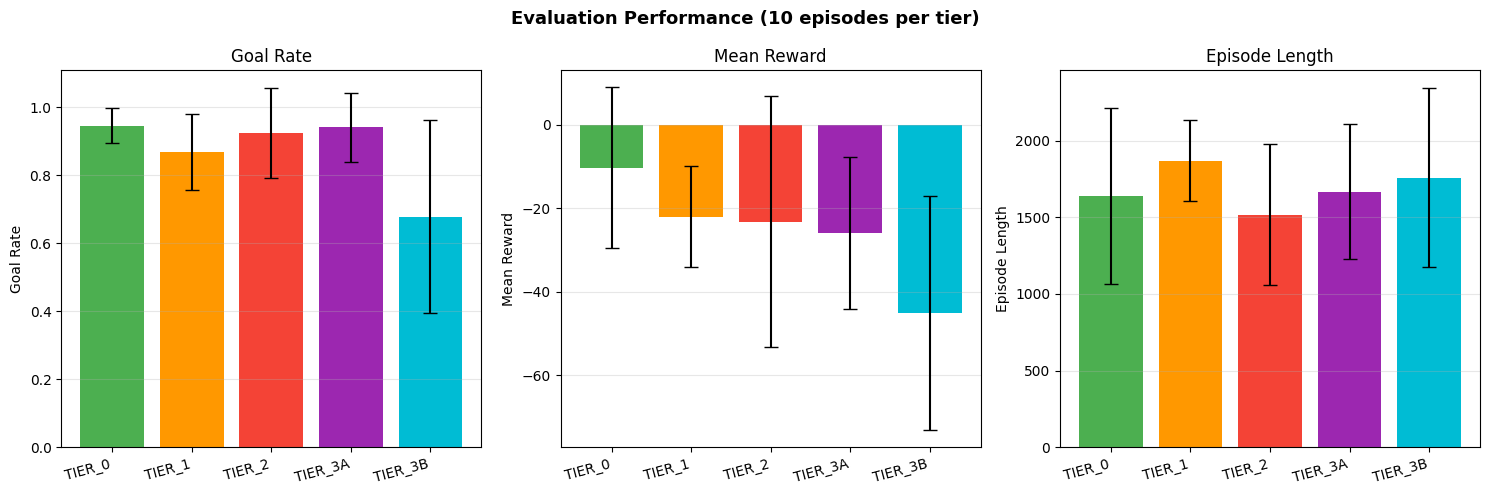

In [9]:
N_EVAL = 10
eval_results = {}

actor_critic.eval()

for tier in [GeometryTier.TIER_0, GeometryTier.TIER_1, GeometryTier.TIER_2,
             GeometryTier.TIER_3A, GeometryTier.TIER_3B]:
    tier_stats = {"goal_rate": [], "mean_reward": [], "episode_length": [], "n_agents": []}

    eval_env_config = CrowdEnvConfig(
        geometry=eval_geometry,
        geometry_tiers=[tier],
        spawn=SpawnConfig(n_agents_range=(8, 25)),
        obs=obs_config,
        reward=reward_config,
        max_steps=2000,
    )
    eval_env = CrowdEnv(config=eval_env_config, seed=SEED + 1000)
    eval_buffer = RolloutBuffer(env_config.obs.obs_dim, env_config.action.action_dim, device)

    for i in range(N_EVAL):
        ep_stats = collect_episode(
            eval_env, actor_critic, eval_buffer, obs_normalizer, None, device
        )
        eval_buffer.clear()
        tier_stats["goal_rate"].append(ep_stats["goal_rate"])
        tier_stats["mean_reward"].append(ep_stats["mean_reward"])
        tier_stats["episode_length"].append(ep_stats["episode_length"])
        tier_stats["n_agents"].append(ep_stats["n_agents"])

    eval_results[tier.name] = tier_stats

actor_critic.train()

print(f"{'Tier':<10} {'GoalRate':>10} {'Reward':>10} {'EpLen':>8} {'Agents':>8}")
print("-" * 50)
for tier_name, stats in eval_results.items():
    print(
        f"{tier_name:<10} "
        f"{np.mean(stats['goal_rate']):>8.3f}\u00b1{np.std(stats['goal_rate']):.3f} "
        f"{np.mean(stats['mean_reward']):>8.2f}\u00b1{np.std(stats['mean_reward']):.2f} "
        f"{np.mean(stats['episode_length']):>6.0f}\u00b1{np.std(stats['episode_length']):.0f} "
        f"{np.mean(stats['n_agents']):>6.1f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tier_names = list(eval_results.keys())
x = np.arange(len(tier_names))
bar_colors = ["#4CAF50", "#FF9800", "#F44336", "#9C27B0", "#00BCD4"]

for ax, metric, ylabel in zip(
    axes,
    ["goal_rate", "mean_reward", "episode_length"],
    ["Goal Rate", "Mean Reward", "Episode Length"],
):
    means = [np.mean(eval_results[t][metric]) for t in tier_names]
    stds = [np.std(eval_results[t][metric]) for t in tier_names]
    ax.bar(x, means, yerr=stds, capsize=5, color=bar_colors)
    ax.set_xticks(x)
    ax.set_xticklabels(tier_names, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Evaluation Performance ({N_EVAL} episodes per tier)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Export

Save the trained policy as ONNX for deployment in JuPedSim.

In [10]:
from crowdrl_train.export import export_onnx
from pathlib import Path

onnx_path = Path("outputs/06_full_training/policy.onnx")
export_onnx(actor_critic.actor, obs_normalizer, onnx_path)
print(f"ONNX policy exported to: {onnx_path}")
print(f"File size: {onnx_path.stat().st_size / 1024:.1f} KB")

from crowdrl_train.train import save_checkpoint

ckpt_path = Path("outputs/06_full_training/checkpoint_final.pt")
save_checkpoint(
    ckpt_path, actor_critic, updater,
    obs_normalizer, reward_normalizer, curriculum,
    total_agent_steps, total_episodes,
)
print(f"Checkpoint saved to: {ckpt_path}")

ONNX policy exported to: outputs/06_full_training/policy.onnx
File size: 346.4 KB
Checkpoint saved to: outputs/06_full_training/checkpoint_final.pt
